In [114]:
# Import libraries for file handling and JSON processing
import os
import json

# Path of the folder containing all IPL JSON files
folder_path = r"C:\Users\sujeet\Downloads\ipl_json"

# Create an empty list to store match data
all_data = []

# Loop through every file in the folder
for file in os.listdir(folder_path):

    # Process only JSON files
    if file.endswith(".json"):

        # Create the full file path
        file_path = os.path.join(folder_path, file)

        # Open and read the JSON file
        with open(file_path, "r", encoding="utf-8") as f:

            # Convert JSON data into Python dictionary
            data = json.load(f)

            # Store match data in the list
            all_data.append(data)

# Print total number of files loaded
print("Total files loaded:", len(all_data))

Total files loaded: 1243


In [115]:
# Check the structure of the first match records 
print(all_data[0].keys())

dict_keys(['meta', 'info', 'innings'])


In [116]:
# Display the detailed information of the first cricket match
print(all_data[0]['info'])

{'balls_per_over': 6, 'city': 'Hyderabad', 'dates': ['2017-04-05'], 'event': {'match_number': 1, 'name': 'Indian Premier League'}, 'gender': 'male', 'match_type': 'T20', 'officials': {'match_referees': ['J Srinath'], 'reserve_umpires': ['N Pandit'], 'tv_umpires': ['A Deshmukh'], 'umpires': ['AY Dandekar', 'NJ Llong']}, 'outcome': {'by': {'runs': 35}, 'winner': 'Sunrisers Hyderabad'}, 'overs': 20, 'player_of_match': ['Yuvraj Singh'], 'players': {'Royal Challengers Bangalore': ['CH Gayle', 'Mandeep Singh', 'TM Head', 'KM Jadhav', 'SR Watson', 'Sachin Baby', 'STR Binny', 'S Aravind', 'TS Mills', 'YS Chahal', 'A Choudhary'], 'Sunrisers Hyderabad': ['DA Warner', 'S Dhawan', 'MC Henriques', 'Yuvraj Singh', 'DJ Hooda', 'BCJ Cutting', 'NV Ojha', 'Bipul Sharma', 'B Kumar', 'A Nehra', 'Rashid Khan']}, 'registry': {'people': {'A Choudhary': '18e6906e', 'A Deshmukh': '6fda55cc', 'A Nehra': '96fd40ae', 'AY Dandekar': '2efc430e', 'B Kumar': '2e81a32d', 'BCJ Cutting': '2e11c706', 'Bipul Sharma': 'c18

In [117]:
# Extract important match details and create a DataFrame

import pandas as pd

matches = []

for match in all_data:

    info = match['info']

    teams = info.get('teams', [])

    matches.append({
        'Date': info.get('dates', [None])[0],
        'City': info.get('city'),
        'Team1': teams[0] if len(teams) > 0 else None,
        'Team2': teams[1] if len(teams) > 1 else None,
        'Venue': info.get('venue')
    })

df = pd.DataFrame(matches)

print(df.head())

         Date       City                        Team1  \
0  2017-04-05  Hyderabad          Sunrisers Hyderabad   
1  2017-04-06       Pune       Rising Pune Supergiant   
2  2017-04-07     Rajkot                Gujarat Lions   
3  2017-04-08     Indore              Kings XI Punjab   
4  2017-04-08  Bengaluru  Royal Challengers Bangalore   

                         Team2                                      Venue  
0  Royal Challengers Bangalore  Rajiv Gandhi International Stadium, Uppal  
1               Mumbai Indians    Maharashtra Cricket Association Stadium  
2        Kolkata Knight Riders     Saurashtra Cricket Association Stadium  
3       Rising Pune Supergiant                     Holkar Cricket Stadium  
4             Delhi Daredevils                      M.Chinnaswamy Stadium  


In [118]:
# Extract winner information from all matches and add it to the DataFrame
winners = []

for match in all_data:
    try:
        winner = match['info']['outcome']['winner']
    except:
        winner = "No Result"

    winners.append(winner)

df['Winner'] = winners

print(df.head())

         Date       City                        Team1  \
0  2017-04-05  Hyderabad          Sunrisers Hyderabad   
1  2017-04-06       Pune       Rising Pune Supergiant   
2  2017-04-07     Rajkot                Gujarat Lions   
3  2017-04-08     Indore              Kings XI Punjab   
4  2017-04-08  Bengaluru  Royal Challengers Bangalore   

                         Team2                                      Venue  \
0  Royal Challengers Bangalore  Rajiv Gandhi International Stadium, Uppal   
1               Mumbai Indians    Maharashtra Cricket Association Stadium   
2        Kolkata Knight Riders     Saurashtra Cricket Association Stadium   
3       Rising Pune Supergiant                     Holkar Cricket Stadium   
4             Delhi Daredevils                      M.Chinnaswamy Stadium   

                        Winner  
0          Sunrisers Hyderabad  
1       Rising Pune Supergiant  
2        Kolkata Knight Riders  
3              Kings XI Punjab  
4  Royal Challengers Bangalor

In [119]:
# Export the DataFrame to a CSV file and confirm successful saving

df.to_csv(r"C:\Users\sujeet\Documents\ipl_matches.csv", index=False)

print("CSV file saved successfully!")

CSV file saved successfully!


In [120]:
# Check whether the saved IPL CSV file exists in the specified location

import os

print(os.path.exists(r"C:\Users\sujeet\Documents\ipl_matches.csv"))

True


In [121]:
# Load the exported CSV file into a new DataFrame and preview the data
import pandas as pd

df2 = pd.read_csv(r"C:\Users\sujeet\Documents\ipl_matches.csv")
print(df2.head())

         Date       City                        Team1  \
0  2017-04-05  Hyderabad          Sunrisers Hyderabad   
1  2017-04-06       Pune       Rising Pune Supergiant   
2  2017-04-07     Rajkot                Gujarat Lions   
3  2017-04-08     Indore              Kings XI Punjab   
4  2017-04-08  Bengaluru  Royal Challengers Bangalore   

                         Team2                                      Venue  \
0  Royal Challengers Bangalore  Rajiv Gandhi International Stadium, Uppal   
1               Mumbai Indians    Maharashtra Cricket Association Stadium   
2        Kolkata Knight Riders     Saurashtra Cricket Association Stadium   
3       Rising Pune Supergiant                     Holkar Cricket Stadium   
4             Delhi Daredevils                      M.Chinnaswamy Stadium   

                        Winner  
0          Sunrisers Hyderabad  
1       Rising Pune Supergiant  
2        Kolkata Knight Riders  
3              Kings XI Punjab  
4  Royal Challengers Bangalor

In [122]:
# Check the current folder where Python is running
import os

print(os.getcwd())

c:\Users\sujeet\OneDrive\Documents


In [123]:
# Search for the IPL CSV file and display its full file path

import os

for root, dirs, files in os.walk(r"C:\Users\sujeet"):
    if "ipl_matches.csv" in files:
        print(os.path.join(root, "ipl_matches.csv"))

C:\Users\sujeet\Documents\ipl_matches.csv
C:\Users\sujeet\OneDrive\Documents\ipl_matches.csv


In [124]:
# Display the names of all CSV files present in the Documents directory

import os

for file in os.listdir(r"C:\Users\sujeet\OneDrive\Documents"):
    if file.endswith(".csv"):
        print(file)

CAWomen.csv
ipl_matches.csv
pincode datasetdata.gov.csv


In [125]:
# Load the IPL matches CSV file and display its dimensions and column names

import pandas as pd

df = pd.read_csv(r"C:\Users\sujeet\Documents\ipl_matches.csv")

print(df.shape)
print(df.columns)

(1243, 6)
Index(['Date', 'City', 'Team1', 'Team2', 'Venue', 'Winner'], dtype='object')


In [126]:
# Count and display the number of wins for each IPL team
print(df["Winner"].value_counts())

Winner
Mumbai Indians                 155
Chennai Super Kings            148
Kolkata Knight Riders          140
Rajasthan Royals               123
Royal Challengers Bangalore    114
Sunrisers Hyderabad            102
Kings XI Punjab                 85
Delhi Daredevils                67
Delhi Capitals                  58
Gujarat Titans                  47
Punjab Kings                    41
Lucknow Super Giants            34
Deccan Chargers                 29
Royal Challengers Bengaluru     29
No Result                       25
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: count, dtype: int64


In [127]:
# Find and display the IPL team with the highest number of match wins
print("Most successful team:")
print(df["Winner"].value_counts().idxmax())

Most successful team:
Mumbai Indians


In [128]:
# Display the highest number of wins achieved by any IPL team
print("Total wins:")
print(df["Winner"].value_counts().max())

Total wins:
155


In [ ]:
# Display the top 10 IPL teams with the highest number of match wins
print(df["Winner"].value_counts().head(10))

Winner
Mumbai Indians                 155
Chennai Super Kings            148
Kolkata Knight Riders          140
Rajasthan Royals               123
Royal Challengers Bangalore    114
Sunrisers Hyderabad            102
Kings XI Punjab                 85
Delhi Daredevils                67
Delhi Capitals                  58
Gujarat Titans                  47
Name: count, dtype: int64


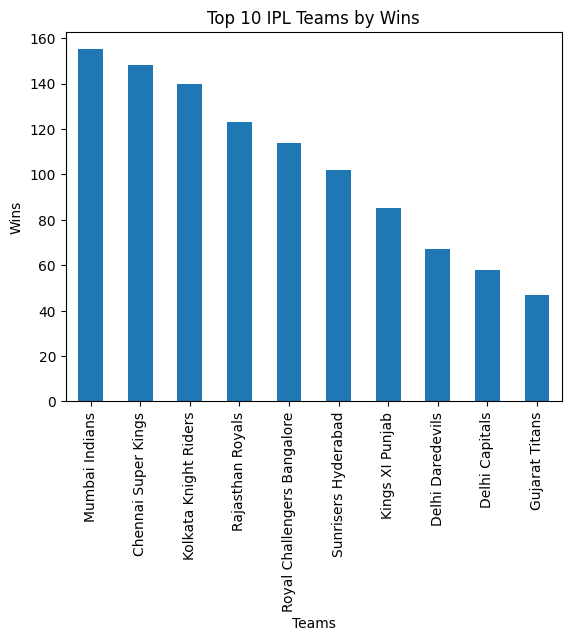

In [ ]:
# Create a bar chart showing the top 10 IPL teams with the highest number of match wins

import matplotlib.pyplot as plt

top10 = df["Winner"].value_counts().head(10)

top10.plot(kind="bar")

plt.title("Top 10 IPL Teams by Wins")
plt.xlabel("Teams")
plt.ylabel("Wins")

plt.show()

In [ ]:
# Display the top 10 cities that hosted the most IPL matches
print(df["City"].value_counts().head(10))

City
Mumbai        187
Kolkata       107
Delhi         104
Chennai        98
Hyderabad      90
Jaipur         68
Bangalore      65
Chandigarh     61
Ahmedabad      53
Pune           51
Name: count, dtype: int64


In [ ]:
# Combine Team1 and Team2 columns and display the top 10 teams with the most IPL match appearances

all_teams = pd.concat([df["Team1"], df["Team2"]])

print(all_teams.value_counts().head(10))

Mumbai Indians                 291
Kolkata Knight Riders          278
Chennai Super Kings            266
Rajasthan Royals               251
Royal Challengers Bangalore    240
Sunrisers Hyderabad            211
Kings XI Punjab                190
Delhi Daredevils               161
Delhi Capitals                 120
Punjab Kings                    88
Name: count, dtype: int64


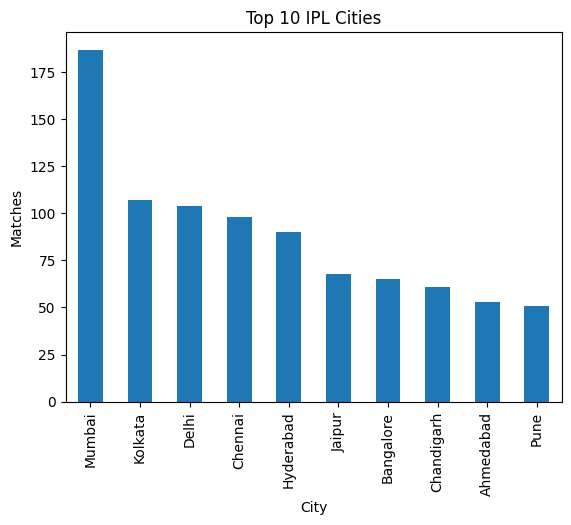

In [ ]:
# Create a bar chart showing the top 10 cities that hosted the most IPL matches
import matplotlib.pyplot as plt

df["City"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 IPL Cities")
plt.xlabel("City")
plt.ylabel("Matches")

plt.show()

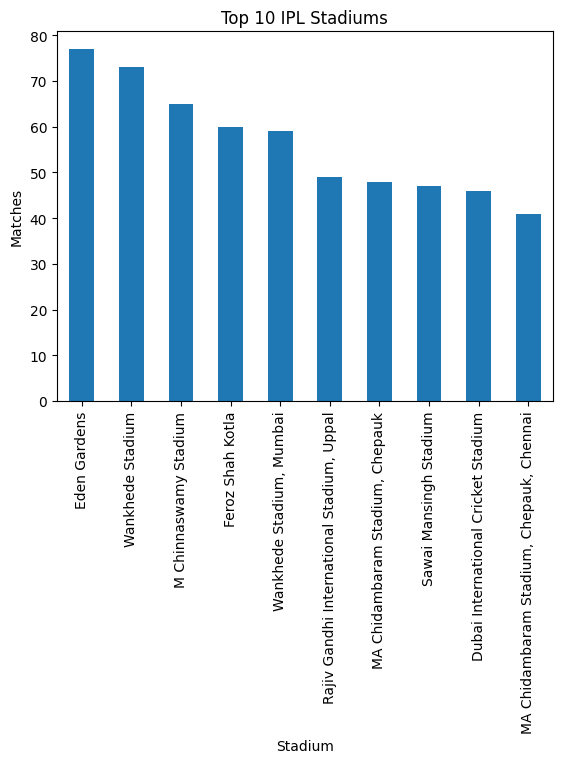

In [ ]:
# Create a bar chart showing the top 10 stadiums that hosted the most IPL matches
df["Venue"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 IPL Stadiums")
plt.xlabel("Stadium")
plt.ylabel("Matches")

plt.show()

In [ ]:
# Calculate and display the top 10 IPL teams with the highest win percentage

matches_played = pd.concat([df["Team1"], df["Team2"]]).value_counts()

wins = df["Winner"].value_counts()

win_percentage = (wins / matches_played * 100).sort_values(ascending=False)

print(win_percentage.head(10))

Royal Challengers Bengaluru    63.043478
Rising Pune Supergiant         62.500000
Gujarat Titans                 61.038961
Chennai Super Kings            55.639098
Mumbai Indians                 53.264605
Kolkata Knight Riders          50.359712
Rajasthan Royals               49.003984
Sunrisers Hyderabad            48.341232
Delhi Capitals                 48.333333
Royal Challengers Bangalore    47.500000
Name: count, dtype: float64


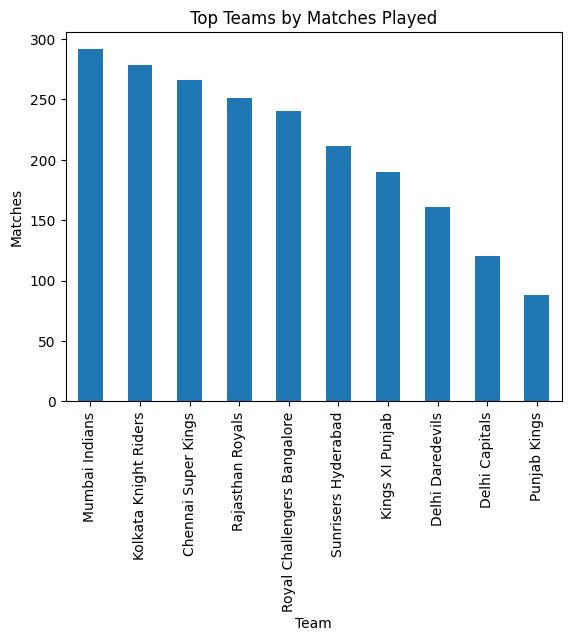

In [ ]:
# Create a bar chart showing the top IPL teams with the highest number of matches played
all_teams.value_counts().head(10).plot(kind="bar")

plt.title("Top Teams by Matches Played")
plt.xlabel("Team")
plt.ylabel("Matches")

plt.show()

In [ ]:
# Display the top 10 IPL teams with the highest number of matches played
matches_played.head(10)

Mumbai Indians                 291
Kolkata Knight Riders          278
Chennai Super Kings            266
Rajasthan Royals               251
Royal Challengers Bangalore    240
Sunrisers Hyderabad            211
Kings XI Punjab                190
Delhi Daredevils               161
Delhi Capitals                 120
Punjab Kings                    88
Name: count, dtype: int64

In [ ]:
# Display the total number of unique cities that have hosted IPL matches
print(df["City"].nunique())

37


In [ ]:
# Display the total number of unique IPL venues (stadiums) in the dataset
print(df["Venue"].nunique())

60


In [ ]:
# Check for missing (null) values in each column of the dataset
print(df.isnull().sum())

Date       0
City      51
Team1      0
Team2      0
Venue      0
Winner     0
dtype: int64


In [ ]:
# Display the first few rows where the City column contains missing values
print(df[df["City"].isnull()].head())

           Date City             Team1                Team2  \
180  2020-09-20  NaN    Delhi Capitals      Kings XI Punjab   
182  2020-11-03  NaN    Mumbai Indians  Sunrisers Hyderabad   
183  2020-09-22  NaN  Rajasthan Royals  Chennai Super Kings   
185  2020-10-24  NaN   Kings XI Punjab  Sunrisers Hyderabad   
187  2020-10-09  NaN    Delhi Capitals     Rajasthan Royals   

                                   Venue               Winner  
180  Dubai International Cricket Stadium            No Result  
182              Sharjah Cricket Stadium  Sunrisers Hyderabad  
183              Sharjah Cricket Stadium     Rajasthan Royals  
185  Dubai International Cricket Stadium      Kings XI Punjab  
187              Sharjah Cricket Stadium       Delhi Capitals  


In [ ]:
# Replace missing values in the City column with 'Unknown'
df["City"] = df["City"].fillna("Unknown")

In [ ]:
# Check for missing (null) values in each column of the dataset
print(df.isnull().sum())

Date      0
City      0
Team1     0
Team2     0
Venue     0
Winner    0
dtype: int64


In [ ]:
# Create an SQLite database and store the cleaned IPL dataset into a table named 'matches'
import sqlite3

conn = sqlite3.connect(r"C:\Users\sujeet\Documents\ipl.db")

df.to_sql("matches", conn, if_exists="replace", index=False)

print("Database created successfully")

Database created successfully


In [ ]:
# Execute an SQL query to retrieve the top 10 IPL teams with the highest number of wins
query = """
SELECT Winner, COUNT(*) as Total_Wins
FROM matches
GROUP BY Winner
ORDER BY Total_Wins DESC
LIMIT 10
"""

result = pd.read_sql(query, conn)

print(result)

                        Winner  Total_Wins
0               Mumbai Indians         155
1          Chennai Super Kings         148
2        Kolkata Knight Riders         140
3             Rajasthan Royals         123
4  Royal Challengers Bangalore         114
5          Sunrisers Hyderabad         102
6              Kings XI Punjab          85
7             Delhi Daredevils          67
8               Delhi Capitals          58
9               Gujarat Titans          47


In [ ]:
# Execute an SQL query to find the top 10 cities that hosted the most IPL matches
query = """
SELECT City, COUNT(*) as Matches
FROM matches
GROUP BY City
ORDER BY Matches DESC
LIMIT 10
"""

result = pd.read_sql(query, conn)

print(result)



         City  Matches
0      Mumbai      187
1     Kolkata      107
2       Delhi      104
3     Chennai       98
4   Hyderabad       90
5      Jaipur       68
6   Bangalore       65
7  Chandigarh       61
8   Ahmedabad       53
9     Unknown       51


In [ ]:
# Execute an SQL query to retrieve the top 10 IPL venues(stadium) that hosted the most matches
query = """
SELECT Venue, COUNT(*) as Matches
FROM matches
GROUP BY Venue
ORDER BY Matches DESC
LIMIT 10
"""

result = pd.read_sql(query, conn)
print(result)

                                       Venue  Matches
0                               Eden Gardens       77
1                           Wankhede Stadium       73
2                      M Chinnaswamy Stadium       65
3                           Feroz Shah Kotla       60
4                   Wankhede Stadium, Mumbai       59
5  Rajiv Gandhi International Stadium, Uppal       49
6            MA Chidambaram Stadium, Chepauk       48
7                     Sawai Mansingh Stadium       47
8        Dubai International Cricket Stadium       46
9           Narendra Modi Stadium, Ahmedabad       41


In [ ]:
# Execute an SQL query to find the top 10 IPL teams appearing most frequently as Team1
query = """
SELECT Team1, COUNT(*) as Matches
FROM matches
GROUP BY Team1
ORDER BY Matches DESC
LIMIT 10
"""

result = pd.read_sql(query, conn)
print(result)

                         Team1  Matches
0          Chennai Super Kings      142
1               Mumbai Indians      139
2  Royal Challengers Bangalore      135
3        Kolkata Knight Riders      134
4             Rajasthan Royals      115
5          Sunrisers Hyderabad      104
6              Kings XI Punjab       92
7             Delhi Daredevils       85
8               Delhi Capitals       52
9                 Punjab Kings       47


In [ ]:
# Execute an SQL query to count the total number of unique cities that hosted IPL matches
query = """
SELECT COUNT(DISTINCT City) as Total_Cities
FROM matches
"""

result = pd.read_sql(query, conn)
print(result)

   Total_Cities
0            38


In [158]:
query = """
SELECT COUNT(DISTINCT Venue) as Total_Stadiums
FROM matches
"""

result = pd.read_sql(query, conn)
print(result)

   Total_Stadiums
0              60


In [ ]:
# Execute an SQL query to count the total number of unique IPL stadiums (venues)
query = """
SELECT Venue, COUNT(*) as Matches
FROM matches
GROUP BY Venue
ORDER BY Matches DESC
LIMIT 10
"""

result = pd.read_sql(query, conn)
print(result)

                                       Venue  Matches
0                               Eden Gardens       77
1                           Wankhede Stadium       73
2                      M Chinnaswamy Stadium       65
3                           Feroz Shah Kotla       60
4                   Wankhede Stadium, Mumbai       59
5  Rajiv Gandhi International Stadium, Uppal       49
6            MA Chidambaram Stadium, Chepauk       48
7                     Sawai Mansingh Stadium       47
8        Dubai International Cricket Stadium       46
9           Narendra Modi Stadium, Ahmedabad       41


In [ ]:
# Execute an SQL query to find cities that hosted more than 50 IPL matches
query = """
SELECT City, COUNT(*) as Matches
FROM matches
GROUP BY City
HAVING COUNT(*) > 50
ORDER BY Matches DESC
"""

result = pd.read_sql(query, conn)
print(result)

          City  Matches
0       Mumbai      187
1      Kolkata      107
2        Delhi      104
3      Chennai       98
4    Hyderabad       90
5       Jaipur       68
6    Bangalore       65
7   Chandigarh       61
8    Ahmedabad       53
9      Unknown       51
10        Pune       51


In [ ]:
# Execute an SQL query to find the latest IPL match date in the dataset
query = """
SELECT MAX(Date) as Latest_Match
FROM matches
"""

result = pd.read_sql(query, conn)
print(result)

  Latest_Match
0   2026-05-31


In [ ]:
# Execute an SQL query to find IPL teams with more than 100 match wins
query = """
SELECT Winner, COUNT(*) as Wins
FROM matches
GROUP BY Winner
HAVING COUNT(*) > 100
ORDER BY Wins DESC
"""

result = pd.read_sql(query, conn)
print(result)

                        Winner  Wins
0               Mumbai Indians   155
1          Chennai Super Kings   148
2        Kolkata Knight Riders   140
3             Rajasthan Royals   123
4  Royal Challengers Bangalore   114
5          Sunrisers Hyderabad   102


In [169]:

# Top 10 Team2 appearances
query = """
SELECT Team2, COUNT(*) AS Matches
FROM matches
GROUP BY Team2
ORDER BY Matches DESC
LIMIT 10;
"""

result = pd.read_sql(query, conn)
print(result)

                         Team2  Matches
0               Mumbai Indians      152
1        Kolkata Knight Riders      144
2             Rajasthan Royals      136
3          Chennai Super Kings      124
4          Sunrisers Hyderabad      107
5  Royal Challengers Bangalore      105
6              Kings XI Punjab       98
7             Delhi Daredevils       76
8               Delhi Capitals       68
9               Gujarat Titans       43


In [170]:
# Number of matches won by each team
query = """
SELECT Winner, COUNT(*) AS Wins
FROM matches
GROUP BY Winner
ORDER BY Wins DESC;
"""
result = pd.read_sql(query, conn)
print(result)

                         Winner  Wins
0                Mumbai Indians   155
1           Chennai Super Kings   148
2         Kolkata Knight Riders   140
3              Rajasthan Royals   123
4   Royal Challengers Bangalore   114
5           Sunrisers Hyderabad   102
6               Kings XI Punjab    85
7              Delhi Daredevils    67
8                Delhi Capitals    58
9                Gujarat Titans    47
10                 Punjab Kings    41
11         Lucknow Super Giants    34
12  Royal Challengers Bengaluru    29
13              Deccan Chargers    29
14                    No Result    25
15                Gujarat Lions    13
16                Pune Warriors    12
17       Rising Pune Supergiant    10
18         Kochi Tuskers Kerala     6
19      Rising Pune Supergiants     5


In [171]:
# Total matches played in Hyderabad
query = """
SELECT COUNT(*) AS Matches
FROM matches
WHERE City='Hyderabad';
"""
result = pd.read_sql(query, conn)
print(result)

   Matches
0       90


In [172]:
# Total matches played in Mumbai
query = """
SELECT COUNT(*) AS Matches
FROM matches
WHERE City='Mumbai';
"""
result = pd.read_sql(query, conn)
print(result)

   Matches
0      187


In [173]:
# Venues hosting more than 40 matches
query = """
SELECT Venue, COUNT(*) AS Matches
FROM matches
GROUP BY Venue
HAVING COUNT(*) > 40;
"""
result = pd.read_sql(query, conn)
print(result)


                                        Venue  Matches
0         Dubai International Cricket Stadium       46
1                                Eden Gardens       77
2                            Feroz Shah Kotla       60
3                       M Chinnaswamy Stadium       65
4             MA Chidambaram Stadium, Chepauk       48
5    MA Chidambaram Stadium, Chepauk, Chennai       41
6            Narendra Modi Stadium, Ahmedabad       41
7   Rajiv Gandhi International Stadium, Uppal       49
8                      Sawai Mansingh Stadium       47
9                            Wankhede Stadium       73
10                   Wankhede Stadium, Mumbai       59


In [174]:
# Number of matches per year
query = """
SELECT SUBSTR(Date,1,4) AS Year, COUNT(*) AS Matches
FROM matches
GROUP BY Year;
"""
result = pd.read_sql(query, conn)
print(result)

    Year  Matches
0   2008       58
1   2009       57
2   2010       60
3   2011       73
4   2012       74
5   2013       76
6   2014       60
7   2015       59
8   2016       60
9   2017       59
10  2018       60
11  2019       60
12  2020       60
13  2021       60
14  2022       74
15  2023       74
16  2024       71
17  2025       74
18  2026       74


In [175]:
 # Distinct teams in the dataset
query = """
SELECT COUNT(DISTINCT Team1) AS Total_Teams
FROM matches;
"""
result = pd.read_sql(query, conn)
print(result)

   Total_Teams
0           19


In [176]:
# Matches where Mumbai Indians won
query = """
SELECT COUNT(*) AS Wins
FROM matches
WHERE Winner='Mumbai Indians';
"""
result = pd.read_sql(query, conn)
print(result)

   Wins
0   155


In [181]:
 #Top 5 cities by matches
query = """
SELECT City, COUNT(*) AS Matches
FROM matches
GROUP BY City
ORDER BY Matches DESC
LIMIT 5;
"""
result = pd.read_sql(query, conn)
print(result)

        City  Matches
0     Mumbai      187
1    Kolkata      107
2      Delhi      104
3    Chennai       98
4  Hyderabad       90


In [182]:
# Teams that never won a match
query = """
SELECT DISTINCT Team1
FROM matches
WHERE Team1 NOT IN (
    SELECT DISTINCT Winner
    FROM matches
);
"""
result = pd.read_sql(query, conn)
print(result)

Empty DataFrame
Columns: [Team1]
Index: []


In [ ]:
# Display the final project summary and key insights from IPL match data analysis

print("Project: Cricsheet Match Data Analysis")
print("")

print("Total Matches: 1243")
print("Total Cities: 38")
print("Total Stadiums: 60")

print("")
print("Key Findings:")
print("1. Mumbai hosted the most IPL matches.")
print("2. Mumbai Indians won the most matches.")
print("3. Eden Gardens hosted the most matches among stadiums.")
print("4. IPL matches were played across 38 cities and 60 stadiums.")
print("5. Data was analyzed using Python, Pandas, SQLite, and SQL queries.")

Project: Cricsheet Match Data Analysis

Total Matches: 1243
Total Cities: 38
Total Stadiums: 60

Key Findings:
1. Mumbai hosted the most IPL matches.
2. Mumbai Indians won the most matches.
3. Eden Gardens hosted the most matches among stadiums.
4. IPL matches were played across 38 cities and 60 stadiums.
5. Data was analyzed using Python, Pandas, SQLite, and SQL queries.
